In [1]:
from os import path
from glob import glob

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

rawdir = '../data/raw/'
resultdir = '../data/results/'

triggers = dict(
    S14='BN STD',
    S15='SN DEV',
    S24='SN STD',
    S25='BN DEV',
    S34='CN STD',
    S35='BN DEV',
)

ch_order = ['TP10', 'CP5', 'C5', 'FC5', 'C6', 'T8', 'C3', 'TP8', 'C4', 'C1', 'P5',
       'FT8', 'CP3', 'F7', 'TP9', 'FC1', 'C2', 'F3', 'FC6', 'TP7', 'F2', 'Fz',
       'FC3', 'Cz', 'P7', 'F1', 'FC2', 'AF3', 'Fp1', 'AFz', 'FC4', 'FCz', 'P8',
       'Fp2', 'FT7', 'P1', 'F8', 'AF4', 'CP2', 'F4', 'P3', 'CPz', 'T7', 'CP1',
       'Pz', 'CP4', 'F5', 'P4', 'PO7', 'CP6', 'AF8', 'AF7', 'FT9', 'P2', 'PO8',
       'P6', 'PO4', 'PO3', 'FT10', 'POz', 'F6', 'O1', 'O2', 'Oz']

%matplotlib widget

Extracting parameters from ../data/raw/sub-sd051/eeg/sub-sd051_task-auditoryoddball_eeg.vhdr...


Setting channel info structure...
Reading 0 ... 3525619  =      0.000 ...  3525.619 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Used Annotations descriptions: ['Stimulus/S   11', 'Stimulus/S   14', 'Stimulus/S   15', 'Stimulus/S   21', 'Stimulus/S   24', 'Stimulus/S   25', 'Stimulus/S   31', 'Stimulus/S   32', 'Stimulus/S   33', 'Stimulus/S   34', 'Stimulus/S   35', 'Stimulus/S10001', 'Stimulus/S99999']
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
2712 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 2712 events and 1001 original time points ...
2 bad epochs dropped


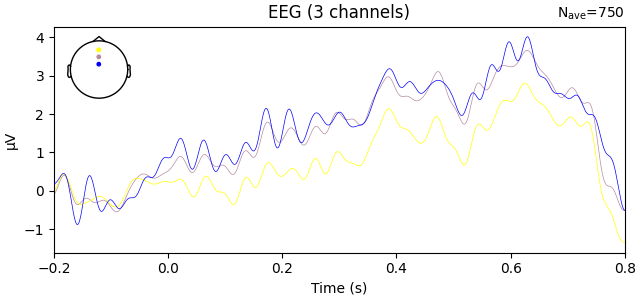

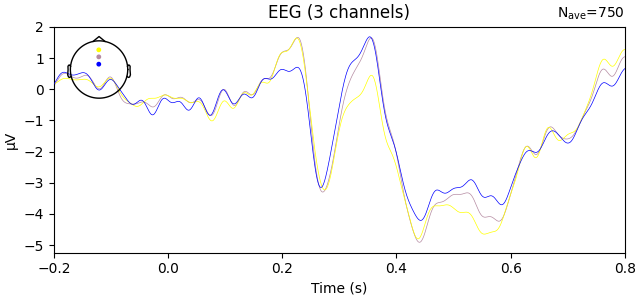

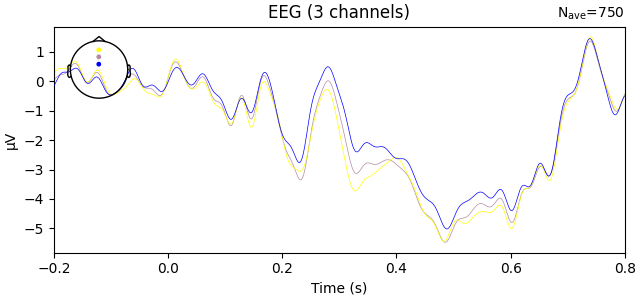

In [2]:
raw = mne.io.read_raw_brainvision('../data/raw/sub-sd051/eeg/sub-sd051_task-auditoryoddball_eeg.vhdr', preload=True)
raw = raw.set_eeg_reference(['TP9', 'TP10'])
raw = raw.filter(0.1, 30, fir_design='firwin')

epochs = mne.Epochs(raw, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, event_repeated='drop').set_montage('standard_1020')

epochs['Stimulus/S   14'].average().plot(spatial_colors=True, picks=['FCz', 'Fz', 'Cz']);
epochs['Stimulus/S   24'].average().plot(spatial_colors=True, picks=['FCz', 'Fz', 'Cz']);
epochs['Stimulus/S   34'].average().plot(spatial_colors=True, picks=['FCz', 'Fz', 'Cz']);

In [38]:
annots = raw.annotations.to_data_frame()
annots['description'] = annots.description.apply(lambda x: int(x.split('/')[1].lstrip('S ')))
annots['description'] = annots.description.replace({99999:7, 10001:6})#.map(lambda x: x%10)
annots.head(30)

,onset,duration,description
0,1970-01-01 00:00:00.000,0.001,7
1,1970-01-01 00:00:00.000,0.001,7
2,1970-01-01 00:00:00.020,0.001,6
3,1970-01-01 00:00:00.020,0.001,6
4,1970-01-01 00:00:21.386,0.001,32
5,1970-01-01 00:00:21.386,0.001,32
6,1970-01-01 00:00:21.398,0.001,31
7,1970-01-01 00:00:21.398,0.001,31
8,1970-01-01 00:00:22.392,0.001,33
9,1970-01-01 00:00:22.392,0.001,33


<Axes: xlabel='onset'>

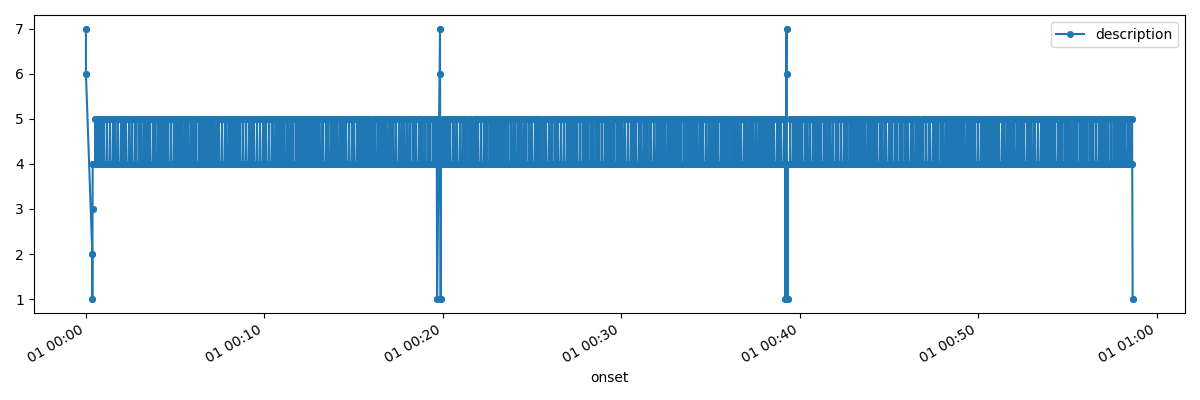

In [22]:
f, ax = plt.subplots(1, 1, figsize=(12, 4), tight_layout=True)
annots.plot(x='onset', y='description', ax=ax, marker='o', markersize=4)

Text(0, 0.5, '$\\Delta t$\n between successive triggers')

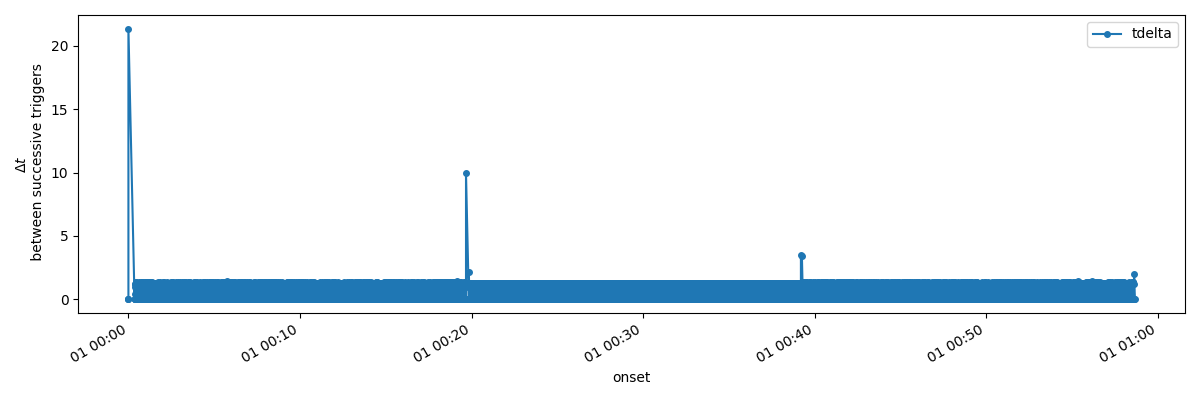

In [37]:
annots['tdelta'] = annots.onset.diff().astype(int).shift(-1)/1e9

f, ax = plt.subplots(1, 1, figsize=(12, 4), tight_layout=True)
annots.plot(x='onset', y='tdelta', ax=ax, marker='o', markersize=4)
ax.set_ylabel('$\Delta t$\n between successive triggers')
# ax.set_ylim(1, 2)

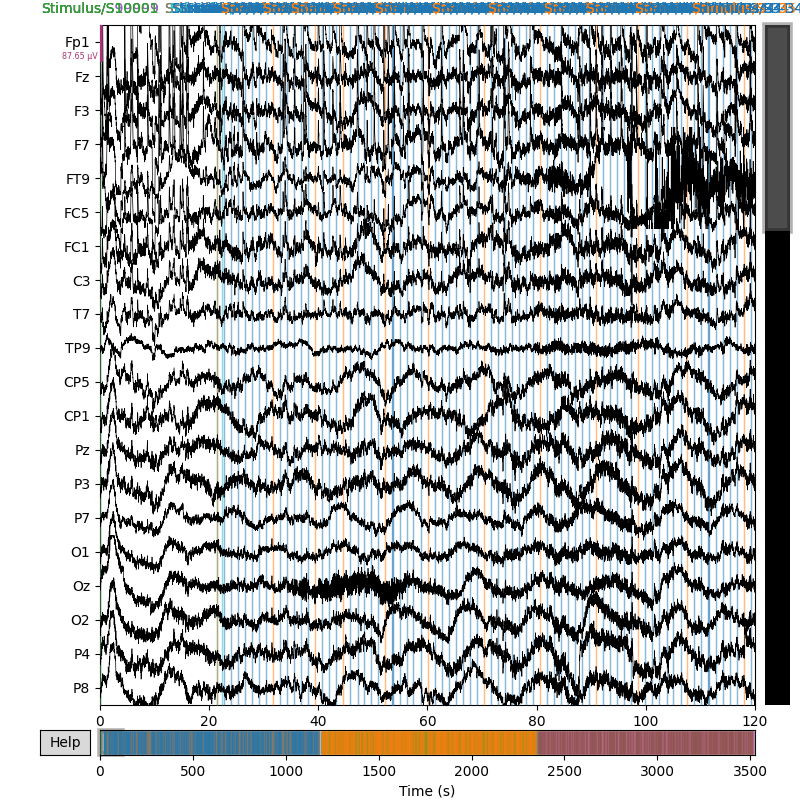

In [37]:
f = raw.plot(duration=120, scalings='auto')

Extracting parameters from ../data/raw/sub-sd055/eeg/sub-sd055_task-auditoryoddball_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 3559259  =      0.000 ...  3559.259 secs...


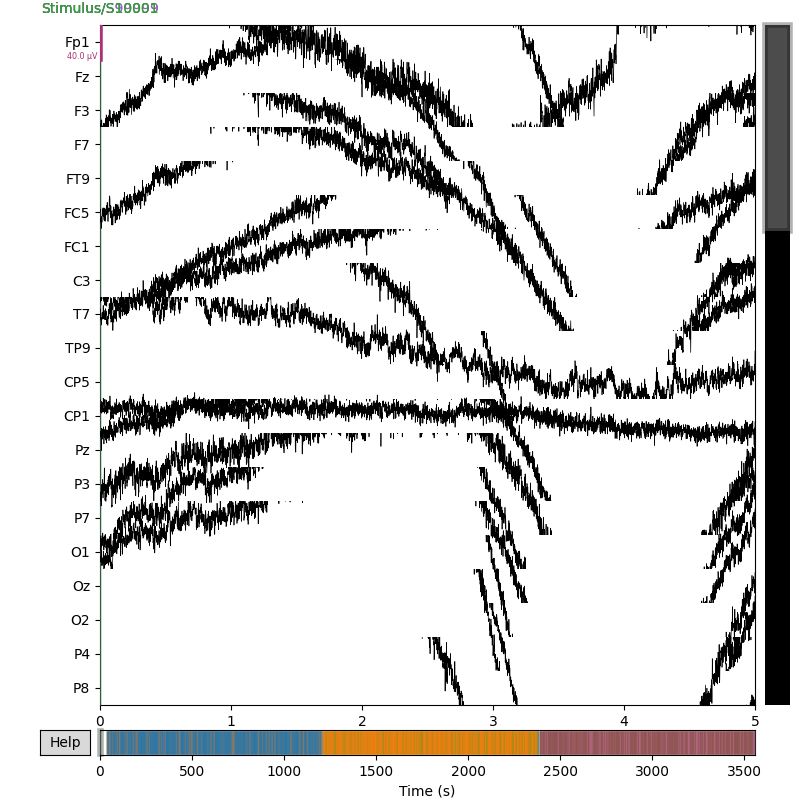

In [8]:
raw2 = mne.io.read_raw_brainvision('../data/raw/sub-sd055/eeg/sub-sd055_task-auditoryoddball_eeg.vhdr', preload=True)
f2 = raw2.plot(duration=5)